# CRI iAtlas notebooks

## Working with data from the PRINCE study.

    Notebook: analyze_PRINCE.ipynb 
    Date: March 16, 2026 
    Author: Vésteinn Thorsson 
---

notebook repo: https://github.com/CRI-iAtlas/iatlas-notebooks

landing page: https://www.cri-iatlas.org/

portal: https://isb-cgc.shinyapps.io/iatlas/

email: support@cri-iatlas.org

---
Welcome to the CRI iAtlas notebooks. With these notebooks you'll be able to recreate many of our figures and modules found in the web portal, but with your own data. That means you can plot your samples next to the samples found in our databases.

This is a jupyter notebook running R. The fastest way to get started is to open the notebook using Jupyter lab in MyBinder, it's free and works great.

If you want to run this on your local environment, you'll need Jupyter (or Visual Studio) and an R kernel to use it.<br>
See [this conda guide](https://docs.anaconda.com/anaconda/navigator/tutorials/r-lang/) or [this datacamp guide](https://www.datacamp.com/community/blog/jupyter-notebook-r) to get started.<br>

First, we'll install needed packages:


In [71]:
try({
    packages = c("magrittr", "dplyr", "feather", "tidyr", "survival", "survminer", "plotly", "repr", "purrr")
    sapply(packages, function(x) {
      if (!require(x,character.only = TRUE))
        install.packages(x)
        library(x,character.only = TRUE)
    })

    if (!require(iatlas.modules)) {
        devtools::install_github("th86/concordanceIndex")
        library(concordanceIndex)
    }
    
    # and our iatlas package from github
    if (!require(iatlas.modules)) {
      devtools::install_github("CRI-iAtlas/iatlas.modules")
      library(iatlas.modules)
    }},
    silent = TRUE
)

Source needed functions. These are functions from the iAtlas app source code, copied here for convenience

In [72]:
source('functions/notebook_functions_2.R')

There are other notebooks in this repository that illustrate functions used to query the iAtlas database to obtain data. We use these functions below.

### Build Data Matrices
Build data frame of feature values. Includes e.g. gene expression signature scores and survival

In [73]:
## use this if you just want to see available features
##features_df <- iatlasGraphQLClient::query_features(cohorts = "PRINCE") 
feature_value_df <- iatlasGraphQLClient::query_feature_values(cohorts = "PRINCE")
feature_value_df <- feature_value_df %>% rename(sample_name=sample) ## expected by later functions
feature_value_df <- feature_value_df %>% mutate(dataset_name="PRINCE") ## expected by later functions

Obtain samples IDs for the PRINCE study

In [74]:
prince_samples  <- iatlasGraphQLClient::query_dataset_samples(datasets = "PRINCE")$sample_name

Build sample matrix containing patient, ICI treatment, and response

In [75]:
m1 <- iatlasGraphQLClient::query_sample_patients(samples=prince_samples) %>% select(sample_name,patient_name)
tags <- c("ICI_Rx","Responder","Response","Sample_Treatment")
m3 <- iatlasGraphQLClient::query_tag_samples_parents(cohort="PRINCE",parent_tags = tags) %>% distinct()
m4 <- m3 %>% select(sample_name,parent_tag_name,tag_short_display)
m5 <- m4 %>% pivot_wider(names_from = parent_tag_name,values_from= tag_short_display)
sample_mat <- m5 %>% inner_join(m1,by="sample_name")

Counts

In [76]:
print(table(sample_mat$Responder))


Non-Responder Not available     Responder 
           50            11            43 


In [77]:
cat("No of samples:",nrow(sample_mat),"\n")
cat("Responder:")
print(table(sample_mat$Responder))
cat("Response:")
print(table(sample_mat$Response))
cat("ICI_Rx:")
print(table(sample_mat$ICI_Rx))
cat("Sample_Treatment:")
print(table(sample_mat$Sample_Treatment))

No of samples: 104 
Responder:
Non-Responder Not available     Responder 
           50            11            43 
Response:
      Not available    Partial Response Progressive Disease      Stable Disease 
                 11                  43                  18                  32 
ICI_Rx:
Nivolumab      None 
       73        31 
Sample_Treatment:
During treatment    Pre-treatment 
              31               73 


We'll build some relevant sample subsets here. In the iAtlas app, these can be made using the Cohort selection. 

Sample IDs for samples obtained prior to ICI treatment, and during treatment

In [78]:
samps_pre <- sample_mat %>% filter(Sample_Treatment=="Pre-treatment") %>% purrr::pluck("sample_name")
samps_during <- sample_mat %>% filter(Sample_Treatment=="During treatment") %>% purrr::pluck("sample_name")

Sample IDs for samples where the response is known

In [79]:
samps_known_response <- sample_mat %>% filter(Response != "Not available") %>% purrr::pluck("sample_name")

##
## Survival plot
##
We construct a data frame using the iAtlas app function `build_survival_df` and plot the survival curves using another function `create_kmplot`.

The primary sample division is by Responder, so let's make a data frame of those values 

In [70]:
df_responder <- iatlasGraphQLClient::query_tag_samples_parents(cohort="PRINCE",parent_tags = "Responder") %>% distinct() %>%
select(sample_name,tag_short_display) %>% rename(group_name=tag_short_display)

Join that to the data frame of feature values (which has the survival data)

In [80]:
df <- feature_value_df %>% left_join(df_responder,by="sample_name")

The secondary division of the samples will be by the Macrophage Regulation signature. Create data frame with that.

In [81]:
extra_group_df <- feature_value_df %>% filter(feature_name=="CSF1_response")

Restrict to pre-treatment samples and corresponding patients for which response is known

In [82]:
df <- df %>% filter(sample_name %in% intersect(samps_pre,samps_known_response))
extra_group_df <- extra_group_df %>% filter(sample_name %in% intersect(samps_pre,samps_known_response))

Build the data frame going that goes into the plot. Here there is an option to include the extra sample group or not. 

In [83]:
df_new <- build_survival_df(df,group_column="group_name", time_column="PFI_time_1", filter_df = TRUE,  extra_group_df , extra_group = "No")
df_surv <- df_new %>% distinct()

The resulting data frame has time, status, measure as columns. We can now fit the survival model and create the plot.

In [29]:
fit <- survival::survfit(survival::Surv(time, status) ~ measure, data = df_surv)

Ignoring unknown labels:
• colour : "Strata"


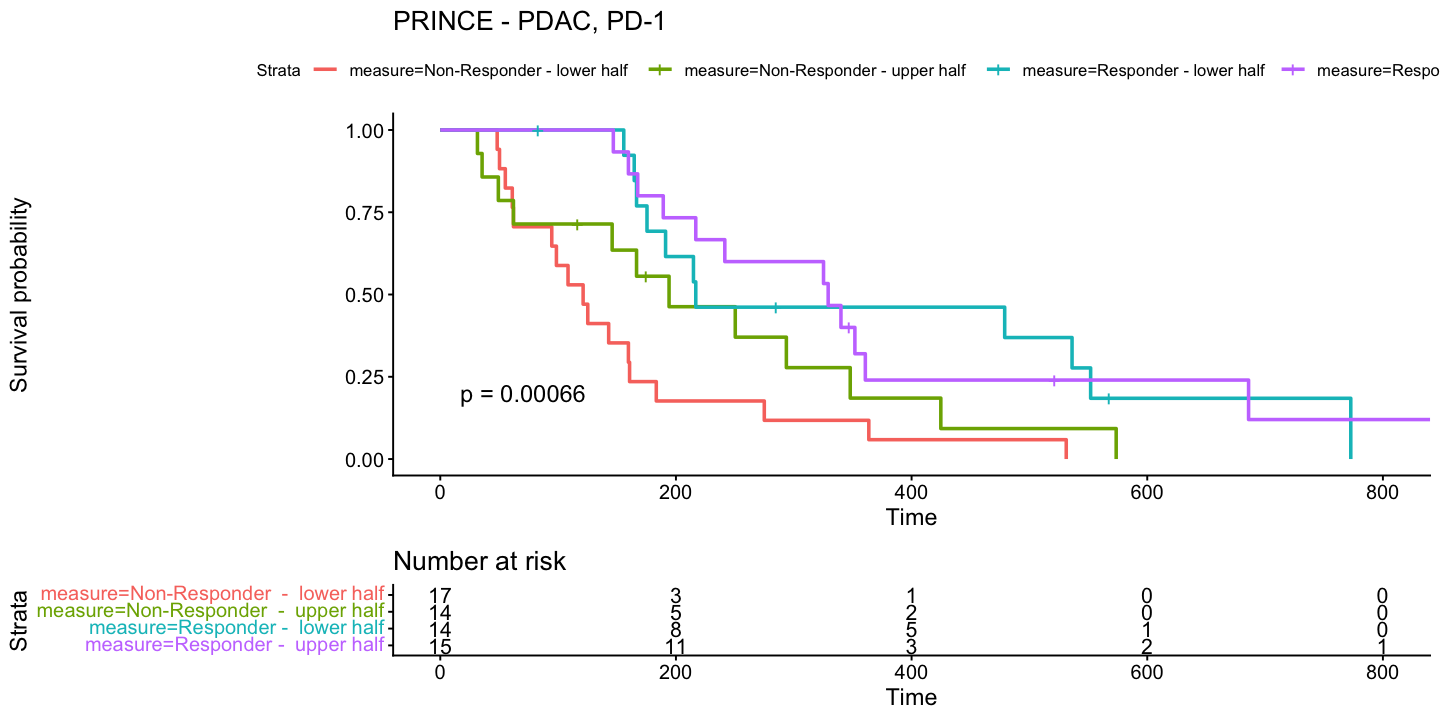

In [85]:
options(repr.plot.width=12, repr.plot.height=6)
create_kmplot(fit, 
              df_surv, 
              confint=FALSE, 
              risktable=TRUE, 
              title="PRINCE - PDAC, PD-1", 
              group_colors=NULL, 
              show_pval = TRUE, 
              show_pval_method = FALSE, 
              facet = FALSE)

### Immunomodulators

This grabs and displays the available immunomodulatory proteins

In [ ]:
immunomodulators <- iatlasGraphQLClient::query_immunomodulators()
head(immunomodulators)

Now let's get the actual values, for IL1A and CD70.

In [ ]:
## This query gets values for all the immumodular genes. It takes a little while to run, so we will illustrate with a smaller query.
##gene_vals <- iatlasGraphQLClient::query_gene_expression(cohorts = "PRINCE", entrez = immunomodulators$entrez)
gene_vals <- iatlasGraphQLClient::query_gene_expression(cohorts = "PRINCE", entrez = c(970,3552))
im_exp <- gene_vals %>% select(-entrez) %>% pivot_wider(names_from = hgnc,values_from=rna_seq_expr, values_fill=NA) %>% rename(sample_name=sample)

Combine with the available sample information

In [91]:
m <- sample_mat %>% inner_join(im_exp,by="sample_name")

Now we can plot the expression, separated by whether patient was a Responder and/or received immune checkpoint inhibition drug. 

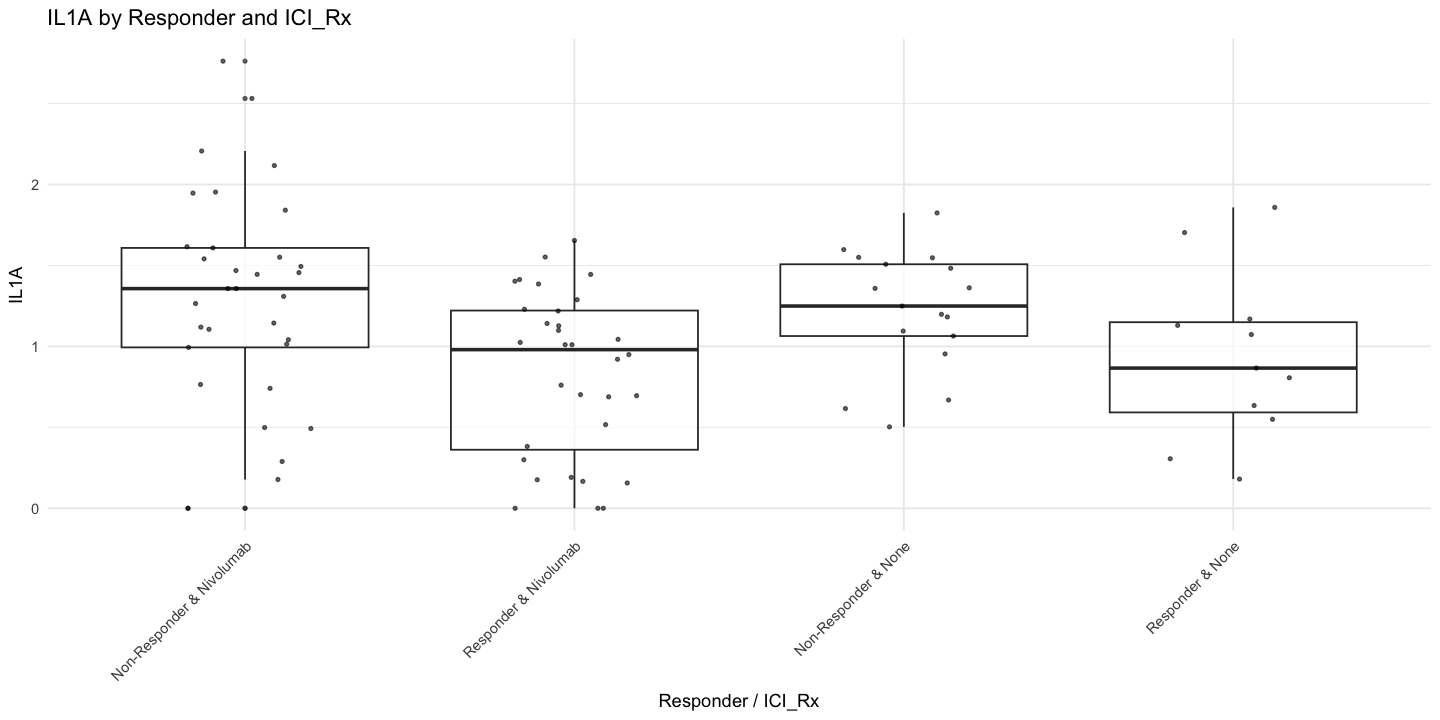

In [ ]:
m %>%
filter(Responder != "Not available") %>%
    filter(!is.na(IL1A), !is.na(Responder), !is.na(ICI_Rx)) %>%
    mutate(IL1A_log10 = log10(IL1A + 1),  Responder_ICI = interaction(Responder, ICI_Rx, sep = " & ")) %>%
    ggplot(aes(x = Responder_ICI, y = IL1A_log10)) +
    geom_boxplot(outlier.size = 0.8, alpha = 0.7) +
    geom_jitter(width = 0.2, size = 0.8, alpha = 0.6) +
    labs(x = "Responder / ICI_Rx", y = "IL1A", title = "IL1A by Responder and ICI_Rx") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))